In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf
import tensorflow as tf

from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.python.keras.utils import np_utils
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from prophet.plot import add_changepoints_to_plot, plot_plotly, plot_components_plotly
from prophet  import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier



# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 새로운 숫자 이미지 예측

## 1. MNIST 데이터셋 로드

In [13]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data() 

## 2. 데이터 정규화 (0.0 ~ 1.0 사이 숫자로)

In [14]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

## 3. 타겟값 범주형으로 (0 ~ 9까지의 그룹)

In [15]:
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

## 4. CNN모델 생성 후 학습

In [16]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Flatten())
model.add(Dense(128,  activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 실행
history = model.fit(X_train, Y_train, 
                    validation_data=(X_test, Y_test), 
                    epochs=10, batch_size=200, verbose=1)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 86s 277ms/step - accuracy: 0.9212 - loss: 0.2599 - val_accuracy: 0.9832 - val_loss: 0.0523
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 76s 255ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9882 - val_loss: 0.0368
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 82s 273ms/step - accuracy: 0.9808 - loss: 0.0619 - val_accuracy: 0.9885 - val_loss: 0.0351
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 101s 338ms/step - accuracy: 0.9847 - loss: 0.0489 - val_accuracy: 0.9890 - val_loss: 0.0302
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 98s 328ms/step - accuracy: 0.9872 - loss: 0.0417 - val_accuracy: 0.9908 - val_loss: 0.0312
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 90s 299ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9905 - val_loss: 0.0295
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 90s 299ms/step - accuracy: 0.9898 - loss: 0.0309 - val_accuracy: 0.9900 - val_loss: 0.0323
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 87s 290ms/step - accuracy: 0.9906 - loss: 

## 5. 새로운 숫자이미지를 입력하고 예측

### 새로운 이미지 불러오기
1. 채널 수 확인 (mode)
2. 흑백채널로 변경
3. imshow 후 배경색과 글씨색을 확인
4. MNIST 형태로 반전
5. 숫자 정규화
6. CNN모델에 입력하여 실행
7. 결과 확인

In [48]:
# test1 = Image.open('../../data/myNumber1.png')
# test1 = Image.open('../../data/myNumber2.png')
test1 = Image.open('../../data/myNumber7.png')
test1.mode

'RGBA'

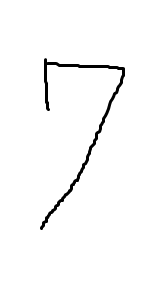

In [49]:
test1

In [50]:
# 흑백 이미지로 변환하기
test1_gray = test1.convert("L") 
test1_gray.mode

'L'

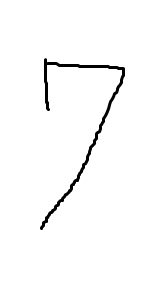

In [51]:
test1_gray

In [52]:
## 그림 크기를 MNIST의 크기인 28x28로 변환
test1_gray = test1_gray.resize((28,28))

In [53]:
test1_data = np.asarray(test1_gray)
print(test1_data)

[[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
  255 255 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 182 205 212 226 226 226 232 235 235 235 235
  240 245 255 255 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 124 215 212 204 204 203 196 197 197 197 195
  189 187 142 250 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 138 241 255 255 255 255 255 255 255 255 255
  255 219 142 253 255 255 255 255 255 255]
 [255 255 255 255 255 255 255 147 225 255 255 255 255 255 255 25

In [54]:
for x in test1_data:
    for i in x:
        print(f'{i:4d}', end='')  # 4자리로 출력, 줄 바꿈 없이 출력
    print()  # 각 행마다 줄 바꿈

 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 182 205 212 226 226 226 232 235 235 235 235 240 245 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 124 215 212 204 204 203 196 197 197 197 195 189 187 142 250 255 255 255 255 255 255
 255 255 255 255 255 255 255 138 241 255 255 255 255 255 255 255 255 255 255 219 142 253 255 255 255 255 255 255
 255 255 255 255 255 255 255 147 225 255 255 255 255 255 255 255 255 255 226 137 239 255 255 255

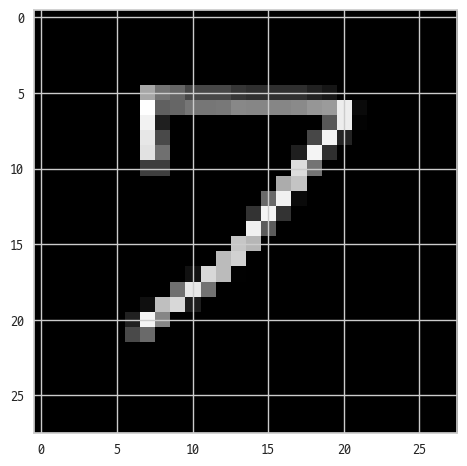

In [55]:
plt.imshow(test1_data, cmap='Grays')

In [56]:
## 벡터값 반전 시키기
test1_data_v = []

for i in range(28):
    row = []
    for j in range(28):                
        row.append(255 - test1_data[i][j])
    test1_data_v.append(row)

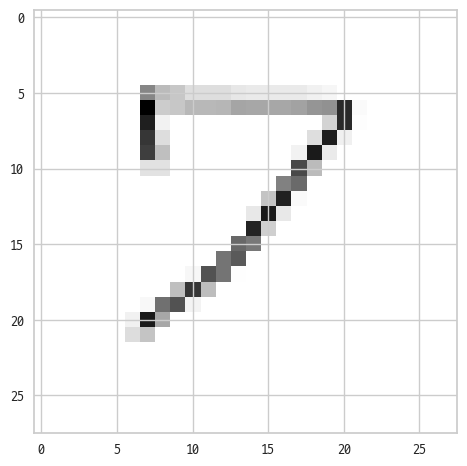

In [57]:
plt.imshow(test1_data_v, cmap='Grays')

In [58]:
## 숫자값 정규화
test1_data_v2 = np.asarray(test1_data_v)
test1_data_v2 = test1_data_v2.reshape(-1, 28, 28, 1).astype('float32') / 255

test1_data_v2.shape

(1, 28, 28, 1)

In [59]:
prediction_new = model.predict(test1_data_v2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [60]:
test1_class = prediction_new.argmax()

print('입력한 이미지는 %f 확률로 %d 입니다!'%(prediction_new[0, test1_class]*100, test1_class))

입력한 이미지는 62.405163 확률로 7 입니다!


In [61]:
for i in range(10):
    print(f"숫자 {i}: {prediction_new[0, i] * 100:.2f}%")

숫자 0: 0.15%
숫자 1: 14.25%
숫자 2: 14.77%
숫자 3: 4.10%
숫자 4: 0.45%
숫자 5: 0.06%
숫자 6: 0.10%
숫자 7: 62.41%
숫자 8: 1.65%
숫자 9: 2.07%
